# 8.2. EEG RNN: Recurrent Neural Nets for Temporal Decoding

**Learning Objectives:**
- Understand how **recurrent neural networks (RNNs)**, especially **LSTMs**, can model EEG time series
- Build a simple **sequence model** that decodes conditions from sensor-level EEG over time
- Learn how to reshape EEG epochs for **sequence modeling** in PyTorch
- Implement training, validation, and test evaluation for an RNN-based decoder
- Compare RNN behavior to the **CNN** from notebook 8.1

**Key Concepts:**
- **Sequence Modeling**: Processing inputs as ordered sequences (time steps)
- **LSTM / GRU Units**: Gated recurrent cells that capture long-range temporal dependencies
- **Many-to-One Architecture**: Using the final hidden state to classify an entire trial
- **Temporal Dynamics**: How information about stimulus identity unfolds over time

We reuse the **MEG/EEG sample dataset** and preprocessing pipeline from previous tutorials but this time we feed the data into a **bidirectional LSTM** that operates directly on the time axis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import mne
from mne.datasets import sample

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

sns.set_context("notebook", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
mne.set_config('MNE_TQDM', 'off')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Load and Prepare EEG/MEG Data

We follow the same steps as in **8.1** to obtain epochs with shape `(n_trials, n_channels, n_times)`
for an **auditory vs visual** decoding task.

In [ ]:
repo_root = Path("./").resolve().parents[1]
target_dir = repo_root / "datasets" / "meg_sample"
target_dir.mkdir(parents=True, exist_ok=True)

data_path = sample.data_path(path=str(target_dir), download=True)

meg_file = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"
events_fname = data_path / 'MEG' / 'sample' / 'sample_audvis_raw-eve.fif'

raw = mne.io.read_raw_fif(meg_file, preload=True)
events = mne.read_events(events_fname)

print(f"Loaded raw data with {len(raw.ch_names)} channels")
print(f"Found {len(events)} events")

Opening raw data file /Users/yibeisita/Documents/neuro-ai-playground/datasets/meg_sample/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
Loaded raw data with 376 channels
Found 320 events


In [ ]:
# Basic preprocessing
raw.filter(l_freq=1.0, h_freq=40.0, n_jobs=1)
raw.pick_types(meg='grad', eeg=False, eog=False, stim=False)

print(f"Filtered data, {len(raw.ch_names)} gradiometer channels")

event_id_separate = {
    'auditory/left': 1,
    'auditory/right': 2,
    'visual/left': 3,
    'visual/right': 4,
}

tmin, tmax = -0.2, 0.5

epochs = mne.Epochs(
    raw,
    events,
    event_id_separate,
    tmin,
    tmax,
    baseline=(None, 0),
    preload=True,
    reject=dict(grad=4000e-13),
    decim=4,  # downsample for speed
)

epochs.events[:, 2] = (epochs.events[:, 2] >= 3).astype(int)
epochs.event_id = {'auditory': 0, 'visual': 1}

X = epochs.get_data()  # (n_epochs, n_channels, n_times)
y = epochs.events[:, 2]

n_samples, n_channels, n_times = X.shape
print(f"Epochs shape: {X.shape}")
print(f"Class balance: auditory={np.sum(y==0)}, visual={np.sum(y==1)}")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtered data, 203 gradiometer channels
Not setting metadata
289 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 289 events and 421 original time points (prior to decimation) ...
0 bad epochs dropped
Epochs shape: (289, 203

## 2. Reshaping for Sequence Modeling & Dataset Class

RNNs in PyTorch expect inputs as `(batch, seq_len, features)`.

We will treat:
- **Time** as the sequence dimension
- **Channels** as features at each time step

So we reshape from `(n_trials, n_channels, n_times)` to `(n_trials, n_times, n_channels)`.

In [4]:
class EEGSequenceDataset(Dataset):
    def __init__(self, X, y):
        # X: (n_trials, n_channels, n_times) -> (n_trials, n_times, n_channels)
        X_seq = np.transpose(X, (0, 2, 1))
        self.X = torch.from_numpy(X_seq.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


dataset = EEGSequenceDataset(X, y)
n_trials, seq_len, n_features = dataset.X.shape
print(f"Sequence dataset shape: (trials={n_trials}, seq_len={seq_len}, features={n_features})")

Sequence dataset shape: (trials=289, seq_len=106, features=203)


## 3. Define a Bidirectional LSTM Classifier

We'll implement a compact **bidirectional LSTM**:

- LSTM over time steps (input size = number of channels)
- Use the **final hidden state** (concatenated forward + backward) as a summary
- Fully connected layer to 2 output classes

This is a simple many-to-one architecture: one label per trial.

In [5]:
class EEGLSTM(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=1, n_classes=2, bidirectional=True, dropout=0.5):
        super().__init__()
        self.n_features = n_features
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
        )
        
        num_directions = 2 if bidirectional else 1
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * num_directions, n_classes)

    def forward(self, x):  # x: (batch, seq_len, features)
        # LSTM returns outputs for each time step and the final hidden state
        out, (h_n, c_n) = self.lstm(x)
        
        # h_n: (num_layers * num_directions, batch, hidden_size)
        if self.bidirectional:
            # Concatenate last layer's forward and backward hidden states
            h_forward = h_n[-2, :, :]  # (batch, hidden_size)
            h_backward = h_n[-1, :, :]
            h = torch.cat([h_forward, h_backward], dim=1)
        else:
            h = h_n[-1, :, :]
        
        h = self.dropout(h)
        logits = self.fc(h)
        return logits


model = EEGLSTM(n_features=n_features, hidden_size=64, num_layers=1, n_classes=2, bidirectional=True).to(device)
print(model)

EEGLSTM(
  (lstm): LSTM(203, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


## 4. Train/Validation/Test Split and DataLoaders

We'll reuse the **StratifiedKFold** strategy from previous notebooks to:

- Build non-overlapping train / validation / test sets
- Keep label balance across splits

Later, you could wrap this RNN inside **cross-validation** as in 7.3.

In [6]:
batch_size = 32
n_epochs = 20
learning_rate = 1e-3

# Train/val/test split indices (stratified)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, temp_idx = next(skf.split(np.zeros_like(y), y))
y_temp = y[temp_idx]

skf_temp = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
_temp_train, temp_val = next(skf_temp.split(np.zeros_like(y_temp), y_temp))
val_idx = temp_idx[temp_val]
test_idx = np.setdiff1d(temp_idx, val_idx)

print(f"Train trials: {len(train_idx)}")
print(f"Val trials:   {len(val_idx)}")
print(f"Test trials:  {len(test_idx)}")

train_ds = EEGSequenceDataset(X[train_idx], y[train_idx])
val_ds = EEGSequenceDataset(X[val_idx], y[val_idx])
test_ds = EEGSequenceDataset(X[test_idx], y[test_idx])

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

Train trials: 231
Val trials:   29
Test trials:  29


In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return running_loss / total, correct / total

In [8]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0
best_state_dict = None

for epoch in range(1, n_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_dict = model.state_dict()

    print(f"Epoch {epoch:02d} | "
          f"Train loss: {train_loss:.3f}, acc: {train_acc:.3f} | "
          f"Val loss: {val_loss:.3f}, acc: {val_acc:.3f}")

# Restore best model
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print(f"\nRestored best model with val acc = {best_val_acc:.3f}")

Epoch 01 | Train loss: 0.696, acc: 0.494 | Val loss: 0.694, acc: 0.483
Epoch 02 | Train loss: 0.694, acc: 0.498 | Val loss: 0.694, acc: 0.483
Epoch 03 | Train loss: 0.694, acc: 0.498 | Val loss: 0.694, acc: 0.483
Epoch 04 | Train loss: 0.691, acc: 0.541 | Val loss: 0.693, acc: 0.517
Epoch 05 | Train loss: 0.692, acc: 0.537 | Val loss: 0.693, acc: 0.517
Epoch 06 | Train loss: 0.694, acc: 0.476 | Val loss: 0.693, acc: 0.517
Epoch 07 | Train loss: 0.696, acc: 0.524 | Val loss: 0.693, acc: 0.517
Epoch 08 | Train loss: 0.693, acc: 0.515 | Val loss: 0.693, acc: 0.517
Epoch 09 | Train loss: 0.695, acc: 0.498 | Val loss: 0.693, acc: 0.517
Epoch 10 | Train loss: 0.692, acc: 0.558 | Val loss: 0.693, acc: 0.517
Epoch 11 | Train loss: 0.696, acc: 0.494 | Val loss: 0.693, acc: 0.483
Epoch 12 | Train loss: 0.691, acc: 0.524 | Val loss: 0.694, acc: 0.483
Epoch 13 | Train loss: 0.694, acc: 0.502 | Val loss: 0.694, acc: 0.483
Epoch 14 | Train loss: 0.693, acc: 0.519 | Val loss: 0.693, acc: 0.483
Epoch 

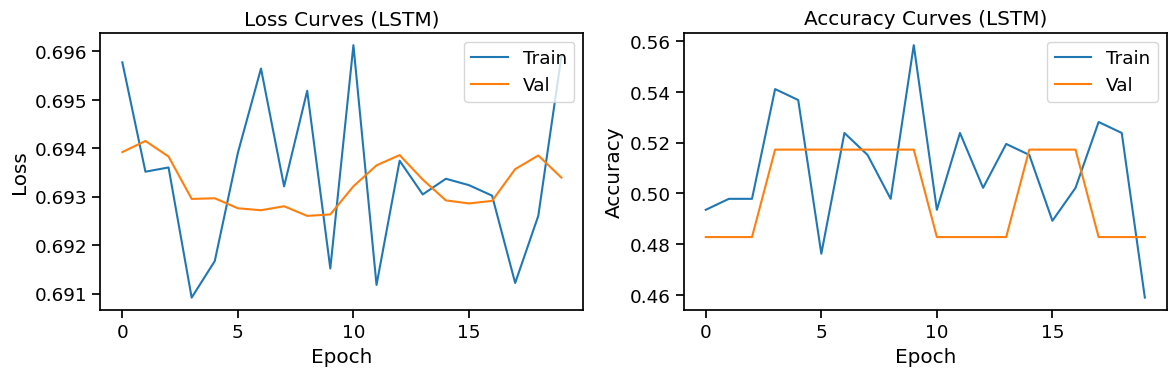

In [9]:
# Plot learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train')
axes[0].plot(val_losses, label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves (LSTM)')
axes[0].legend()

axes[1].plot(train_accs, label='Train')
axes[1].plot(val_accs, label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curves (LSTM)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Test Set Evaluation

We now evaluate the **held-out test set** to get an unbiased estimate of RNN performance.

You can compare this to the **CNN test accuracy** from notebook 8.1.

In [10]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test loss (LSTM): {test_loss:.3f}")
print(f"Test accuracy (LSTM): {test_acc:.3f}")

# Collect predictions for confusion matrix
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_true.append(y_batch.numpy())

all_preds = np.concatenate(all_preds)
all_true = np.concatenate(all_true)

cm = confusion_matrix(all_true, all_preds)
print("\nConfusion matrix (LSTM):")
print(cm)

print("\nClassification report (LSTM):")
print(classification_report(all_true, all_preds, target_names=['auditory', 'visual']))

Test loss (LSTM): 0.693
Test accuracy (LSTM): 0.517

Confusion matrix (LSTM):
[[ 0 14]
 [ 0 15]]

Classification report (LSTM):
              precision    recall  f1-score   support

    auditory       0.00      0.00      0.00        14
      visual       0.52      1.00      0.68        15

    accuracy                           0.52        29
   macro avg       0.26      0.50      0.34        29
weighted avg       0.27      0.52      0.35        29

